# Chapter 2: Redux

In [8]:
import pandas as pd
import os
import numpy as np

In [9]:
# Getting the data 
pwd = os.getcwd()
filepath = os.path.join(pwd, "housing.csv")
filepath

'c:\\Users\\mathe\\OneDrive\\Desktop\\Hands-On-Machine_learning\\Hands_On_Machine_Learning\\Chapter_2\\housing.csv'

In [10]:
# Reading the data from a CSV file
housing_data = pd.read_csv(filepath)
housing_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [11]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


<Axes: ylabel='ocean_proximity'>

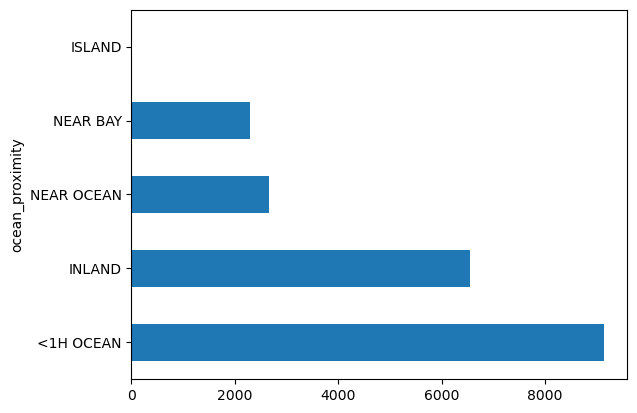

In [12]:
housing_data["ocean_proximity"].value_counts().plot(kind="barh")

In [13]:
housing_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
# ✅ pd.cut()
# This splits a continuous numerical variable into intervals or bins. It creates a new categorical column based on the bin each value falls into.

# ✅ bins=[0., 1.5, 3.0, 4.5, 6., np.inf]
# This defines the boundaries of the bins:
# 
# 0 to 1.5 → bin 1
# 
# 1.5 to 3.0 → bin 2
# 
# 3.0 to 4.5 → bin 3
# 
# 4.5 to 6.0 → bin 4
# 
# 6.0 to ∞ → bin 5
# 
# Each value in median_income is assigned to one of these bins based on where it falls.

# ✅ labels=[1, 2, 3, 4, 5]
# These are the labels assigned to each bin. Instead of showing intervals like (0.0, 1.5], the bins will just be labeled as integers 1 through 5.

# So now the column income_cat will have values from 1 to 5 depending on the range into which the original median_income fell.


housing_data["income_cat"] = pd.cut(housing_data["median_income"],
                                    # inf means to infinity
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])
# Counts how many data points fall into each income category (bin). This helps analyze the distribution of income levels in your dataset.
housing_data["income_cat"].value_counts()

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64

<Axes: >

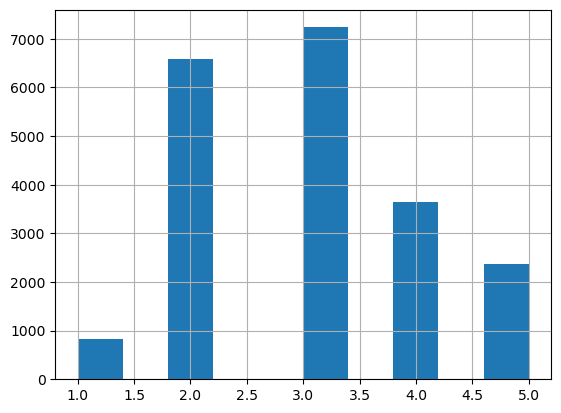

In [16]:
housing_data["income_cat"].hist()

In [ ]:
# Creating the X dataset and Y dataset X = Features/Column Y = Label/row
y = housing_data["median_house_value"]
# Dropping the median house value column
X = housing_data.drop("median_house_value", axis=1)
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY,3
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND,2
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND,2
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND,2
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND,2


# Splitting our Dataset

We want to do this before any substantial visualizations that way we can avoid biases inherent to the visualization process

In [21]:
from sklearn.model_selection import train_test_split
# Splitting the train dataset from the the test dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

<Axes: >

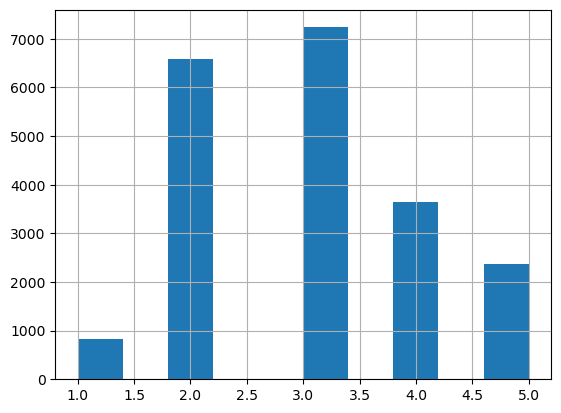

In [ ]:
# visualizing the new income category data 
housing_data["income_cat"].hist()

<Axes: >

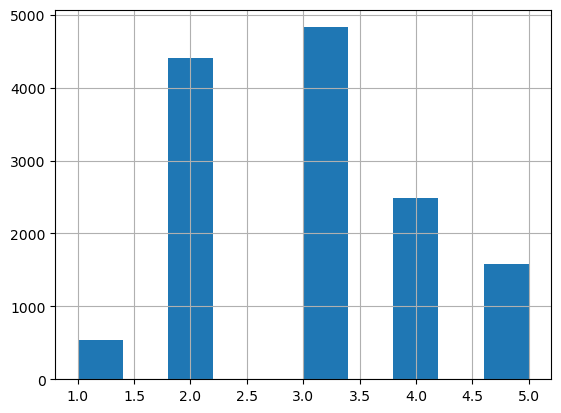

In [ ]:
# visualizing the new X_train income category data 
# to see the actual global distribution of the data from the actual data before split if the distribution is not right use stratified
X_train["income_cat"].hist()

<Axes: >

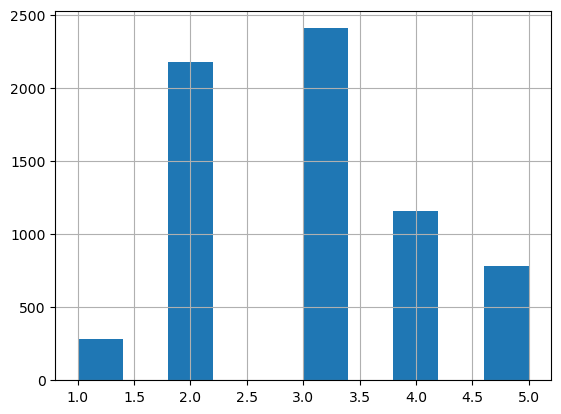

In [ ]:
# visualizing the new X_test income category data 
# to see the actual global distribution of the data from the actual data before split if the distribution is not right use stratified
X_test["income_cat"].hist()

## Stratified Splits

Sometimes we might want to split our data in a stratified manner. This means, based on a specific column we will want our train and test sets to have the same approximate distribution. This is especially important with small datasets. Because this dataset is as large as it is we don't have to do this but I feel it's good to see how the code works for something like this. 

In [24]:
from sklearn.model_selection import StratifiedShuffleSplit
# this is going to split out data using the income category  to make sure that the income category column percentage is evenly distributed
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing_data, housing_data["income_cat"]):
    strat_train_set = housing_data.loc[train_index]
    strat_test_set = housing_data.loc[test_index]

In [ ]:
# strat_test_set["income_cat"].value_counts()
# Counts how many rows fall into each income category (1 through 5) in the strat_test_set.

# len(strat_test_set)
# Gets the total number of rows in the test set.

# Dividing the count of each category by the total number of rows gives the percentage of each category in the set.
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

# Why do this?
# You're likely doing stratified sampling—meaning you're splitting the dataset into train/test sets while preserving the distribution of income categories.

# This line helps verify that the test set has a similar distribution of income_cat as the full dataset.

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [26]:
housing_data["income_cat"].value_counts() / len(housing_data)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [ ]:
# This function compare the overall percentage error Multiply by one hundred
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing_data, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing_data),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.039971,0.040213,0.973236,0.364964
2,0.318847,0.318798,0.324370,1.732260,-0.015195
3,0.350581,0.350533,0.358527,2.266446,-0.013820
4,0.176308,0.176357,0.167393,-5.056334,0.027480
5,0.114438,0.114341,0.109496,-4.318374,-0.084674


In [ ]:
# We are going to use the strat_train_set and the strat_test_set for training and testing we do not need the income_cat anymore
strat_train_set.drop("income_cat", axis="columns", inplace=True)
strat_test_set.drop("income_cat", axis="columns", inplace=True)

# Visualizing our Data

Data visualization is a very important part of any modeling process. Statistics alone can very rarely tell us what we need to know about a dataset. Visualizing data can even reveal obvious patterns that we didn't notice between datasets because all of the measures of central tendancy (mean, median, mode) are the exact same between them. 

In [ ]:
# Visualizing the strat_train_set data 
housing = strat_train_set.copy()

### Anscombe's Quartet

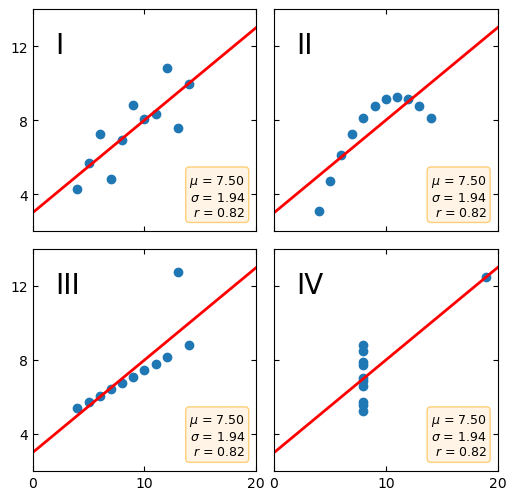

In [ ]:
# You don't have to write down this code, it is purely here to illustrate the importance of data visualization
# Code from: https://matplotlib.org/stable/gallery/specialty_plots/anscombe.html
# This is a custom code for diagram plot
import matplotlib.pyplot as plt
x = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
y1 = [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]
y2 = [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]
y3 = [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]
x4 = [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8]
y4 = [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]

datasets = {
    'I': (x, y1),
    'II': (x, y2),
    'III': (x, y3),
    'IV': (x4, y4)
}

fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(6, 6),
                        gridspec_kw={'wspace': 0.08, 'hspace': 0.08})
axs[0, 0].set(xlim=(0, 20), ylim=(2, 14))
axs[0, 0].set(xticks=(0, 10, 20), yticks=(4, 8, 12))

for ax, (label, (x, y)) in zip(axs.flat, datasets.items()):
    ax.text(0.1, 0.9, label, fontsize=20, transform=ax.transAxes, va='top')
    ax.tick_params(direction='in', top=True, right=True)
    ax.plot(x, y, 'o')

    # linear regression
    p1, p0 = np.polyfit(x, y, deg=1)  # slope, intercept
    ax.axline(xy1=(0, p0), slope=p1, color='r', lw=2)

    # add text box for the statistics
    stats = (f'$\\mu$ = {np.mean(y):.2f}\n'
             f'$\\sigma$ = {np.std(y):.2f}\n'
             f'$r$ = {np.corrcoef(x, y)[0][1]:.2f}')
    bbox = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
    ax.text(0.95, 0.07, stats, fontsize=9, bbox=bbox,
            transform=ax.transAxes, horizontalalignment='right')

### Histograms

Histograms are a great way to start off the visualization process. They help us the the distribution of our data.

array([[<AxesSubplot:title={'center':'longitude'}>,
        <AxesSubplot:title={'center':'latitude'}>,
        <AxesSubplot:title={'center':'housing_median_age'}>],
       [<AxesSubplot:title={'center':'total_rooms'}>,
        <AxesSubplot:title={'center':'total_bedrooms'}>,
        <AxesSubplot:title={'center':'population'}>],
       [<AxesSubplot:title={'center':'households'}>,
        <AxesSubplot:title={'center':'median_income'}>,
        <AxesSubplot:title={'center':'median_house_value'}>]],
      dtype=object)

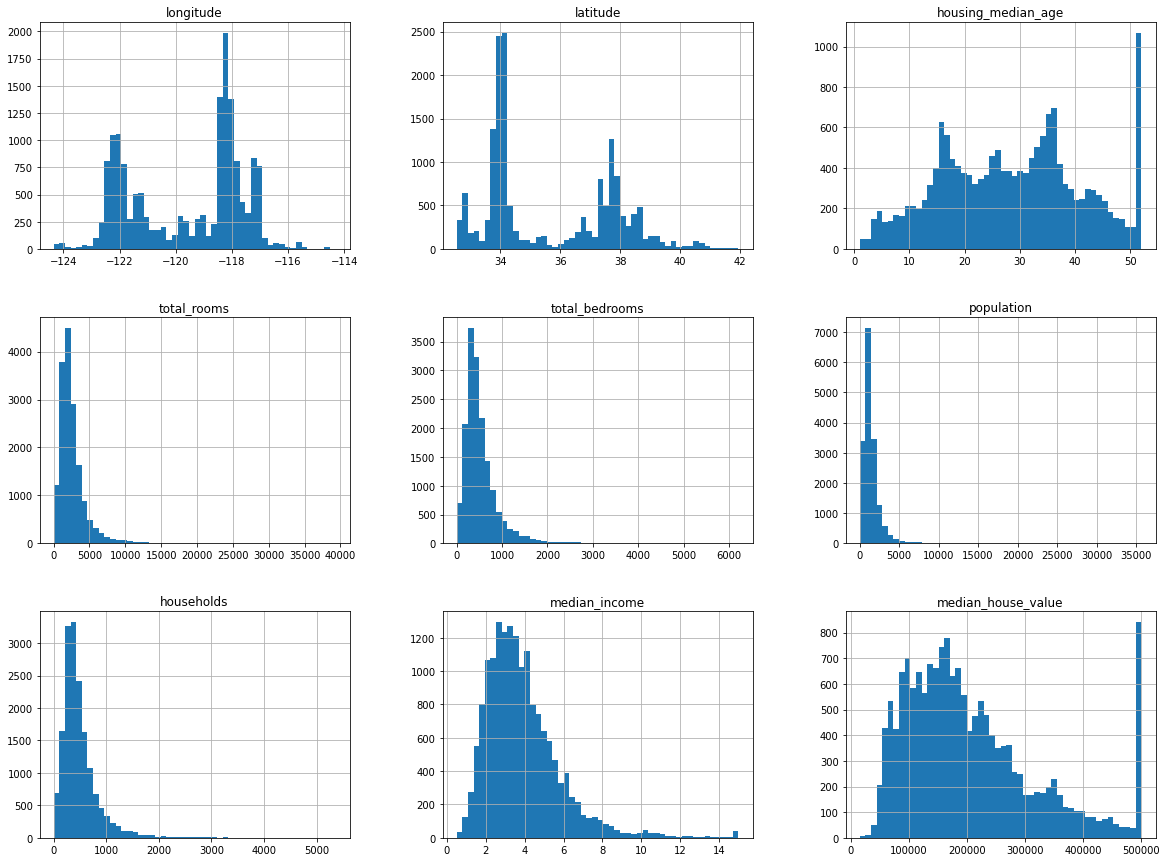

In [49]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20, 15))

<Axes: >

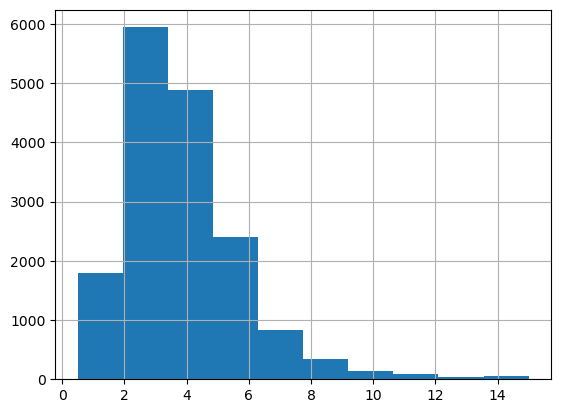

In [36]:
housing["median_income"].hist()

### Plotting Geographic Data

If you have longitudes and latitudes you should plot them on a map to see what patterns reveal themselves. I highly recommend doing this kind of visualization in Tableau or PowerBI. PowerBI is free on Windows, and Tableau has a Public version which is free on Mac or Windows. You'll save a lot of time and have an output that looks better and is easy to make different iterations of. 

<Axes: xlabel='longitude', ylabel='latitude'>

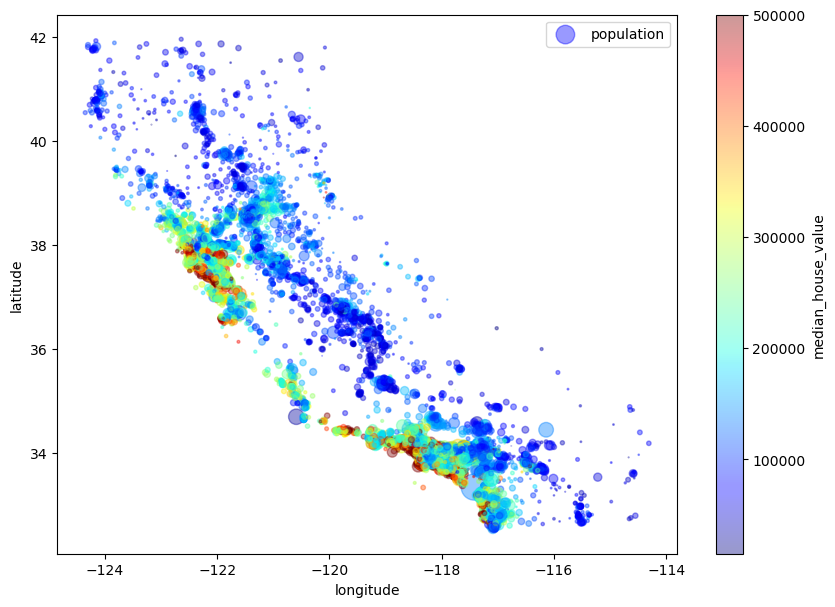

In [37]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
             sharex=False)

In [29]:
# import plotly.express as px
# px.scatter_geo(housing_data, lat="latitude", lon="longitude", color="median_house_value", size="population")

# I tried this, it's too slow

### Correlation Matrices

A correlation matrix is grid that shows the correlation coefficient of every numerical variable against every other numerical variable. It can be a good way to quickly see which variables are of particular interest for your target variable

In [ ]:
# Checking the correlation between the variable to be calculated
# housing.corr()

ValueError: could not convert string to float: 'INLAND'

In [41]:
import seaborn as sns
import numpy as np
# Checking the correlation between the variable to be calculated
housing.corr()
corr = housing.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

ValueError: could not convert string to float: 'INLAND'

# Preparing Data for Machine Learning

Data preparation is oftentimes the most time-consuming step of the modeling process. It is also one of the most important with model accuracy often contingent on the quality of data inserted. To this end, we'll be applying the following transformations on this data, not in this particular order:

-  **Feature Engineering:** Creating new features (columns) out of our raw data using domain knowledge

- **Imputation:** Inserting values where they might be missing to have a complete dataset

- **Encoding Categorical Variables:** Transforming categorical variables into some numerical variation

- **Scaling:** Applying a scaler that transforms all of our data on the same numerical scale 

In [ ]:
# Drop median_house_value column not row 
housing = strat_train_set.drop("median_house_value", axis=1)
# Store the new start_train_set to the housing_labels variable
housing_labels = strat_train_set["median_house_value"].copy()

### Dealing with missing values

Many machine learning algorithms don't work very well with missing values. Becuase of this we need to learn to deal with them. First let's see if we can find the values that we're interested in.

In [45]:
# Checking for missing values
sample_incomplete_rows = housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rows
# If any missing values found we have three options

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
1606,-122.08,37.88,26.0,2947.0,NaN,825.0,626.0,2.9330,NEAR BAY,2
10915,-117.87,33.73,45.0,2264.0,NaN,1970.0,499.0,3.4193,<1H OCEAN,3
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN,3
4186,-118.23,34.13,48.0,1308.0,NaN,835.0,294.0,4.2891,<1H OCEAN,3
16885,-122.40,37.58,26.0,3281.0,NaN,1145.0,480.0,6.3580,NEAR OCEAN,5


#### Option 1: Drop the rows with missing values in any columns

In [46]:
# Drop the row with the missing value completely if any
sample_incomplete_rows.dropna(subset=["total_bedrooms"]) 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat


#### Option 2: Drop the columns with missing values

In [47]:
# Drop the column with the missing value completely if any
sample_incomplete_rows.drop("total_bedrooms", axis=1) 

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity,income_cat
1606,-122.08,37.88,26.0,2947.0,825.0,626.0,2.9330,NEAR BAY,2
10915,-117.87,33.73,45.0,2264.0,1970.0,499.0,3.4193,<1H OCEAN,3
19150,-122.70,38.35,14.0,2313.0,954.0,397.0,3.7813,<1H OCEAN,3
4186,-118.23,34.13,48.0,1308.0,835.0,294.0,4.2891,<1H OCEAN,3
16885,-122.40,37.58,26.0,3281.0,1145.0,480.0,6.3580,NEAR OCEAN,5


#### Option 3: Impute (fill in) the values with some replacement value. This can be a completely different value like -999 so the algorithm will learn that the value is missing, or the mean or median or mode of the column

In [48]:
# We will use imputation to fill missing values if any
median = housing["total_bedrooms"].median()
sample_incomplete_rows["total_bedrooms"].fillna(median, inplace=True) # option 3

C:\Users\mathe\AppData\Local\Temp\ipykernel_9980\4110001610.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sample_incomplete_rows["total_bedrooms"].fillna(median, inplace=True) # option 3


In [280]:
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
4629,-118.30,34.07,18.0,3759.0,433.0,3296.0,1462.0,2.2708,<1H OCEAN
6068,-117.86,34.01,16.0,4632.0,433.0,3038.0,727.0,5.1762,<1H OCEAN
17923,-121.97,37.35,30.0,1955.0,433.0,999.0,386.0,4.6328,<1H OCEAN
13656,-117.30,34.05,6.0,2155.0,433.0,1039.0,391.0,1.6675,INLAND
19252,-122.79,38.48,7.0,6837.0,433.0,3468.0,1405.0,3.1662,<1H OCEAN


In [ ]:
from sklearn.impute import SimpleImputer
# Calling the imputer method to filling  the missing the data
imputer = SimpleImputer(strategy="median")

Only keep numerical columns

In [ ]:
# Store the housing data to the housing_num
housing_num = housing.select_dtypes(include=[np.number])

In [283]:
housing_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
17606,-121.89,37.29,38.0,1568.0,351.0,710.0,339.0,2.7042
18632,-121.93,37.05,14.0,679.0,108.0,306.0,113.0,6.4214
14650,-117.20,32.77,31.0,1952.0,471.0,936.0,462.0,2.8621
3230,-119.61,36.31,25.0,1847.0,371.0,1460.0,353.0,1.8839
3555,-118.59,34.23,17.0,6592.0,1525.0,4459.0,1463.0,3.0347
...,...,...,...,...,...,...,...,...
6563,-118.13,34.20,46.0,1271.0,236.0,573.0,210.0,4.9312
12053,-117.56,33.88,40.0,1196.0,294.0,1052.0,258.0,2.0682
13908,-116.40,34.09,9.0,4855.0,872.0,2098.0,765.0,3.2723
11159,-118.01,33.82,31.0,1960.0,380.0,1356.0,356.0,4.0625


In [ ]:
# Fitting the imputed data (housing_num)
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [ ]:
# Getting the newly imputed fitting data values
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [53]:
X = imputer.transform(housing_num)

housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing.index)

housing_tr.loc[sample_incomplete_rows.index.values]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
1606,-122.08,37.88,26.0,2947.0,433.0,825.0,626.0,2.9330
10915,-117.87,33.73,45.0,2264.0,433.0,1970.0,499.0,3.4193
19150,-122.70,38.35,14.0,2313.0,433.0,954.0,397.0,3.7813
4186,-118.23,34.13,48.0,1308.0,433.0,835.0,294.0,4.2891
16885,-122.40,37.58,26.0,3281.0,433.0,1145.0,480.0,6.3580


In [54]:
imputer.strategy

'median'

In [288]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
17606,-121.89,37.29,38.0,1568.0,351.0,710.0,339.0,2.7042
18632,-121.93,37.05,14.0,679.0,108.0,306.0,113.0,6.4214
14650,-117.20,32.77,31.0,1952.0,471.0,936.0,462.0,2.8621
3230,-119.61,36.31,25.0,1847.0,371.0,1460.0,353.0,1.8839
3555,-118.59,34.23,17.0,6592.0,1525.0,4459.0,1463.0,3.0347


### Encoding Categorical Data

In [74]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
17606,<1H OCEAN
18632,<1H OCEAN
14650,NEAR OCEAN
3230,INLAND
3555,<1H OCEAN
19480,INLAND
8879,<1H OCEAN
13685,INLAND
4937,<1H OCEAN
4861,<1H OCEAN


In [75]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[0.],
       [0.],
       [4.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.]])

In [76]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [79]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(sparse=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

housing_cat_1hot# Creates a "dense array" meaning that all instances have a value not just the ones that are encoded

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       ...,
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [80]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

### Feature Engineering

Feature engineering is the art/science of using domain knowledge to create new features (columns) of data using raw data. This can be key to improving the performance of your Machine Learning models.  

In [86]:
def feature_engineering(data):
    data["bedrooms_per_household"] = data["total_bedrooms"] / data["households"]
    data["population_per_household"] = data["population"] / data["households"]
    data["rooms_per_household"] = data["total_rooms"] / data["households"]

    return data

In [87]:
housing_feature_engineered = feature_engineering(housing_num)
housing_feature_engineered

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household
17606,-121.89,37.29,38.0,1568.0,351.0,710.0,339.0,2.7042,4.625369,2.094395
18632,-121.93,37.05,14.0,679.0,108.0,306.0,113.0,6.4214,6.008850,2.707965
14650,-117.20,32.77,31.0,1952.0,471.0,936.0,462.0,2.8621,4.225108,2.025974
3230,-119.61,36.31,25.0,1847.0,371.0,1460.0,353.0,1.8839,5.232295,4.135977
3555,-118.59,34.23,17.0,6592.0,1525.0,4459.0,1463.0,3.0347,4.505810,3.047847
...,...,...,...,...,...,...,...,...,...,...
6563,-118.13,34.20,46.0,1271.0,236.0,573.0,210.0,4.9312,6.052381,2.728571
12053,-117.56,33.88,40.0,1196.0,294.0,1052.0,258.0,2.0682,4.635659,4.077519
13908,-116.40,34.09,9.0,4855.0,872.0,2098.0,765.0,3.2723,6.346405,2.742484
11159,-118.01,33.82,31.0,1960.0,380.0,1356.0,356.0,4.0625,5.505618,3.808989


### Scaling our Data

Many machine learning algorithms don't work well with unscaled data. For example, the magnitude of values in the "total_rooms" feature is going to be substantially higher than that in the "median_income" feature (because the median_income is scaled down by 1000). Because of this we usually will need to scale our values. There are multiple ways to accomplish this, and we will use the StandardScaler which will scale our values to their z-score within their column like so:

z = (x - u) / s

Where x is the value we're scaling, u is the mean of the column, and s is the standard deviation

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

housing_scaled = scaler.fit_transform(housing_feature_engineered)
housing_scaled

array([[-1.15604281,  0.77194962,  0.74333089, ..., -0.61493744,
        -0.31205452, -0.08649871],
       [-1.17602483,  0.6596948 , -1.1653172 , ...,  1.33645936,
         0.21768338, -0.03353391],
       [ 1.18684903, -1.34218285,  0.18664186, ..., -0.5320456 ,
        -0.46531516, -0.09240499],
       ...,
       [ 1.58648943, -0.72478134, -1.56295222, ..., -0.3167053 ,
         0.3469342 , -0.03055414],
       [ 0.78221312, -0.85106801,  0.18664186, ...,  0.09812139,
         0.02499488,  0.06150916],
       [-1.43579109,  0.99645926,  1.85670895, ..., -0.15779865,
        -0.22852947, -0.09586294]])

### Concatenating with Categorical Variables

In [95]:
ml_input_data = np.hstack([housing_cat_1hot, housing_scaled])

array([[ 1.        ,  0.        ,  0.        , ..., -0.61493744,
        -0.31205452, -0.08649871],
       [ 1.        ,  0.        ,  0.        , ...,  1.33645936,
         0.21768338, -0.03353391],
       [ 0.        ,  0.        ,  0.        , ..., -0.5320456 ,
        -0.46531516, -0.09240499],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.3167053 ,
         0.3469342 , -0.03055414],
       [ 1.        ,  0.        ,  0.        , ...,  0.09812139,
         0.02499488,  0.06150916],
       [ 0.        ,  0.        ,  0.        , ..., -0.15779865,
        -0.22852947, -0.09586294]])

In [92]:
housing_feature_engineered

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,population_per_household
17606,-121.89,37.29,38.0,1568.0,351.0,710.0,339.0,2.7042,4.625369,2.094395
18632,-121.93,37.05,14.0,679.0,108.0,306.0,113.0,6.4214,6.008850,2.707965
14650,-117.20,32.77,31.0,1952.0,471.0,936.0,462.0,2.8621,4.225108,2.025974
3230,-119.61,36.31,25.0,1847.0,371.0,1460.0,353.0,1.8839,5.232295,4.135977
3555,-118.59,34.23,17.0,6592.0,1525.0,4459.0,1463.0,3.0347,4.505810,3.047847
...,...,...,...,...,...,...,...,...,...,...
6563,-118.13,34.20,46.0,1271.0,236.0,573.0,210.0,4.9312,6.052381,2.728571
12053,-117.56,33.88,40.0,1196.0,294.0,1052.0,258.0,2.0682,4.635659,4.077519
13908,-116.40,34.09,9.0,4855.0,872.0,2098.0,765.0,3.2723,6.346405,2.742484
11159,-118.01,33.82,31.0,1960.0,380.0,1356.0,356.0,4.0625,5.505618,3.808989


### Pipelines

Pipelines are a feature built into sklearn that allow us to easily apply a number of transformations one after another. There is a little bit of complexity associated with them that leads me to exclude them in this chapter. We will most likely go over them in another chapter. 

Instead we'll just create our own version of a pipeline using a normal Python function.

In [209]:
housing = strat_train_set.drop("median_house_value", axis=1)

housing_labels = strat_train_set["median_house_value"].copy()

def data_transformations(data):

    ### Separate Labels if they Exist ###

    if "median_house_value" in data.columns:
        labels = data["median_house_value"]
        data = data.drop("median_house_value", axis=1)
        
    else:
        labels = None

    ### Feature Engineering ###
    feature_engineered_data = feature_engineering(data)
    features = list(feature_engineered_data.columns) # Creating a list of our features for future use

    ### Imputing Data ###
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy="median")

    housing_num = feature_engineered_data.select_dtypes(include=[np.number])
    imputed = imputer.fit_transform(housing_num)

    ### Encoding Categorical Data ###
    housing_cat = feature_engineered_data.select_dtypes(exclude=[np.number])

    from sklearn.preprocessing import OneHotEncoder
    cat_encoder = OneHotEncoder(sparse=False)
    housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
    features = features + cat_encoder.categories_[0].tolist()
    features.remove("ocean_proximity") # We're encoding this variable, so we don't need it in our list anymore


    ### Scaling Numerical Data ###
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()

    housing_scaled = scaler.fit_transform(imputed)

    ### Concatening all Data ###
    output = np.hstack([housing_scaled, housing_cat_1hot])

    return output, labels, features

In [210]:
cat_encoder.categories_[0].tolist()

['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN']

# Select and Train a Model

## Transform our data using the "pipeline" we created 

We now need to create a clean training dataset to "train" our machine learning regressors, and a "test" set to test the accuracy of said regressors. Let's input our stratified samples into our "pipeline"

In [211]:
train_data, train_labels, features= data_transformations(strat_train_set)
train_data

array([[-1.15604281,  0.77194962,  0.74333089, ...,  0.        ,
         0.        ,  0.        ],
       [-1.17602483,  0.6596948 , -1.1653172 , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.18684903, -1.34218285,  0.18664186, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 1.58648943, -0.72478134, -1.56295222, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.78221312, -0.85106801,  0.18664186, ...,  0.        ,
         0.        ,  0.        ],
       [-1.43579109,  0.99645926,  1.85670895, ...,  0.        ,
         1.        ,  0.        ]])

In [212]:
train_labels

17606    286600.0
18632    340600.0
14650    196900.0
3230      46300.0
3555     254500.0
           ...   
6563     240200.0
12053    113000.0
13908     97800.0
11159    225900.0
15775    500001.0
Name: median_house_value, Length: 16512, dtype: float64

In [213]:
test_data, test_labels, features = data_transformations(strat_test_set)
test_data

array([[ 0.57471497, -0.69620912,  0.03285951, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.83839441, -0.86074221,  0.82471029, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.24635944, -0.65390061, -0.12551065, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.52496413, -0.66800344,  0.19122966, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.10704893, -0.75732141, -0.12551065, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.31601062,  0.55894333, -0.75899128, ...,  0.        ,
         0.        ,  0.        ]])

In [214]:
test_labels

5241     500001.0
10970    240300.0
20351    218200.0
6568     182100.0
13285    121300.0
           ...   
20519     76400.0
17430    134000.0
4019     311700.0
12107    133500.0
2398      78600.0
Name: median_house_value, Length: 4128, dtype: float64

In [215]:
features

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'rooms_per_household',
 'population_per_household',
 '<1H OCEAN',
 'INLAND',
 'ISLAND',
 'NEAR BAY',
 'NEAR OCEAN']

## Linear Regression

In [ ]:
# Running a Linear Regression model Steps
# 1 Import the the Model from SKlearn
from sklearn.linear_model import LinearRegression
# 2. Linear Regression Object
lin_reg = LinearRegression()
# 3. Fit the data and perform machine learning

#  How do the train_data relate to the train_label
lin_reg.fit(train_data, train_labels)
# Run prediction

LinearRegression()

In [1]:
# Compare against some Test Data

original_values = test_labels[:5]

# lin_reg predict this test_data
predicted_values = lin_reg.predict(test_data[:5])

comparison_dataframe = pd.DataFrame(data={"Original Values":original_values, "Predicted Values":predicted_values})

comparison_dataframe["Differences"] = comparison_dataframe["Original Values"] - comparison_dataframe["Predicted Values"]

comparison_dataframe

NameError: name 'test_labels' is not defined

In [218]:
from sklearn.metrics import mean_squared_error

lin_mse = mean_squared_error(original_values, predicted_values)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

45085.12299701141

In [137]:
# Bring in the Metrics

from sklearn.metrics import mean_absolute_error

lin_mae = mean_absolute_error(original_values, predicted_values)
lin_mae

38184.27219647262

## Decision Tree Regressor

In [ ]:
# Running a Linear Regression model Steps
# 1 Import the the model from SKIlearn
from sklearn.tree import DecisionTreeRegressor

# 2. Linear Regression Object
# without random_state=42 the model give me diffrent result every single time its calld a probablelistic model not a detamainlistic model
tree_reg = DecisionTreeRegressor(random_state=42)
# 3. Fit the data and perform machine learning
#  How do the train_data relate to the train_label
tree_reg.fit(train_data, train_labels)
# Run prediction

DecisionTreeRegressor(random_state=42)

In [142]:
train_predictions = tree_reg.predict(train_data)
tree_mse = mean_squared_error(train_labels, train_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

0.0

### Cross Validation

It seems our performance above was top notch. Instead of just splitting our data into a train and test set and training once, we can do something called *K-Fold Cross-Validation* which will split our training dataset into 10 folds (sections) training on 9 of the sections and testing on the last one. It does this for all of the folds which can let us more rigorously evaluate the model.  

In [143]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, train_data, train_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [144]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [69608.72141399 69514.95832579 67440.00670475 71023.22770284
 71824.66133954 74357.72770421 72691.42915506 70615.78473818
 76044.37642103 68197.05871399]
Mean: 71131.79522193872
Standard deviation: 2547.6767025189947


In [ ]:
lin_scores = cross_val_score(lin_reg, train_data, train_labels,
                             scoring="neg_mean_squared_error", cv=10 )
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [67461.9308165  67232.2484863  68224.22888082 74716.58955656
 68420.26897488 71610.91469695 65201.58349349 68686.9304607
 72262.5140762  68112.28697795]
Mean: 69192.94964203317
Standard deviation: 2674.1447265970105


## Random Forest Regressor

In [146]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(train_data, train_labels)

RandomForestRegressor(random_state=42)

In [147]:
train_predictions = forest_reg.predict(train_data)
forest_mse = mean_squared_error(train_labels, train_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

18547.875935484157

In [149]:
# This can take a while depending on how fast your computer is

from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, train_data, train_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [49428.57758404 47240.05944234 49732.51356862 52274.14642477
 49193.2104798  53541.08320838 48624.03350642 47902.76213392
 53245.64279257 49857.75655498]
Mean: 50103.97856958466
Standard deviation: 2076.4217152058145


In [150]:
scores = cross_val_score(lin_reg, train_data, train_labels, scoring="neg_mean_squared_error", cv=10)
pd.Series(np.sqrt(-scores)).describe()

count       10.000000
mean     69192.949642
std       2818.796043
min      65201.583493
25%      67624.519857
50%      68322.248928
75%      70879.918638
max      74716.589557
dtype: float64

## Fine-Tuning the Model

After you pick a model or set of models that are promising, you'll need to fine-tune the hyperparameters (parameters of the model that aren't affected by training) in order to find the best ones to use for your model. You can use something called Grid Search in order to accomplish this. 

In [152]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training 
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(train_data, train_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [153]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 30}

In [154]:
grid_search.best_estimator_

RandomForestRegressor(max_features=6, n_estimators=30, random_state=42)

In [155]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

65024.47660978679 {'max_features': 2, 'n_estimators': 3}
55369.58978707593 {'max_features': 2, 'n_estimators': 10}
52731.776536992475 {'max_features': 2, 'n_estimators': 30}
58623.47382079766 {'max_features': 4, 'n_estimators': 3}
52378.443485146185 {'max_features': 4, 'n_estimators': 10}
49915.83301453051 {'max_features': 4, 'n_estimators': 30}
58073.52955246902 {'max_features': 6, 'n_estimators': 3}
51649.66912253651 {'max_features': 6, 'n_estimators': 10}
49646.50294423546 {'max_features': 6, 'n_estimators': 30}
57472.01873934156 {'max_features': 8, 'n_estimators': 3}
51544.15086663861 {'max_features': 8, 'n_estimators': 10}
49785.394663324856 {'max_features': 8, 'n_estimators': 30}
62702.100868011206 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
54548.25859526867 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
60336.27046883448 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
51884.13018796243 {'bootstrap': False, 'max_features': 3, 'n_estimators'

In [156]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,param_bootstrap,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.058804,0.005484,0.003806,0.001171,2,3,NaN,"{'max_features': 2, 'n_estimators': 3}",-4.213076e+09,-4.326567e+09,...,-4.228183e+09,1.555263e+08,18,-1.179138e+09,-1.153108e+09,-1.090899e+09,-1.124356e+09,-1.150783e+09,-1.139657e+09,2.991642e+07
1,0.196789,0.016003,0.009772,0.001131,2,10,NaN,"{'max_features': 2, 'n_estimators': 10}",-2.934780e+09,-3.197654e+09,...,-3.065791e+09,1.058080e+08,11,-5.784546e+08,-5.819307e+08,-5.537310e+08,-5.811761e+08,-5.674866e+08,-5.725558e+08,1.074301e+07
2,0.519032,0.030856,0.025498,0.002412,2,30,NaN,"{'max_features': 2, 'n_estimators': 30}",-2.563679e+09,-2.926035e+09,...,-2.780640e+09,1.474877e+08,9,-4.377405e+08,-4.260882e+08,-4.214714e+08,-4.401489e+08,-4.255473e+08,-4.301993e+08,7.356394e+06
3,0.092504,0.004651,0.003482,0.000134,4,3,NaN,"{'max_features': 4, 'n_estimators': 3}",-3.250705e+09,-3.516381e+09,...,-3.436712e+09,1.186033e+08,15,-9.400841e+08,-9.294620e+08,-9.128206e+08,-9.866596e+08,-9.266876e+08,-9.391428e+08,2.529998e+07
4,0.293454,0.020849,0.008896,0.000515,4,10,NaN,"{'max_features': 4, 'n_estimators': 10}",-2.445434e+09,-2.900465e+09,...,-2.743501e+09,1.758011e+08,8,-4.934495e+08,-5.061416e+08,-5.005304e+08,-5.372917e+08,-5.120577e+08,-5.098942e+08,1.501662e+07
5,0.971221,0.130311,0.027584,0.003180,4,30,NaN,"{'max_features': 4, 'n_estimators': 30}",-2.271841e+09,-2.601212e+09,...,-2.491590e+09,1.416698e+08,3,-3.839376e+08,-3.803028e+08,-3.732428e+08,-3.926347e+08,-3.839668e+08,-3.828170e+08,6.276186e+06
6,0.142249,0.005149,0.003965,0.000526,6,3,NaN,"{'max_features': 6, 'n_estimators': 3}",-3.118585e+09,-3.425787e+09,...,-3.372535e+09,1.612756e+08,14,-8.623625e+08,-8.871349e+08,-8.954233e+08,-8.696166e+08,-8.979139e+08,-8.824903e+08,1.412503e+07
7,0.414973,0.045456,0.009806,0.001298,6,10,NaN,"{'max_features': 6, 'n_estimators': 10}",-2.488960e+09,-2.720107e+09,...,-2.667688e+09,1.307886e+08,6,-4.863637e+08,-4.890131e+08,-4.976668e+08,-5.025810e+08,-4.819742e+08,-4.915198e+08,7.538211e+06
8,1.196335,0.116219,0.026052,0.002124,6,30,NaN,"{'max_features': 6, 'n_estimators': 30}",-2.288970e+09,-2.512921e+09,...,-2.464775e+09,1.380809e+08,1,-3.747125e+08,-3.765566e+08,-3.768241e+08,-3.803121e+08,-3.712783e+08,-3.759367e+08,2.950101e+06
9,0.173354,0.012016,0.003781,0.000551,8,3,NaN,"{'max_features': 8, 'n_estimators': 3}",-3.104598e+09,-3.357682e+09,...,-3.303033e+09,1.033620e+08,12,-8.629217e+08,-8.523493e+08,-8.426132e+08,-9.130922e+08,-8.622785e+08,-8.666510e+08,2.438098e+07


### Randomized Search

Randomized search allows you to more easily find the hyperparameters that we're interested in because instead of searching through all possible combinations, it randomly picks a couple and tries those out. 

In [157]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=8),
    }

forest_reg = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
rnd_search.fit(train_data, train_labels)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   param_distributions={'max_features': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7fd963a66850>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7fd9629d82e0>},
                   random_state=42, scoring='neg_mean_squared_error')

In [158]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

48674.494176227934 {'max_features': 7, 'n_estimators': 180}
50385.388074239265 {'max_features': 5, 'n_estimators': 15}
50038.274115389526 {'max_features': 3, 'n_estimators': 72}
49797.21638435765 {'max_features': 5, 'n_estimators': 21}
48850.051182500196 {'max_features': 7, 'n_estimators': 122}
50020.22732186308 {'max_features': 3, 'n_estimators': 75}
49976.77970304856 {'max_features': 3, 'n_estimators': 88}
48871.43494723857 {'max_features': 5, 'n_estimators': 100}
49873.1996512147 {'max_features': 3, 'n_estimators': 150}
62126.424275011974 {'max_features': 5, 'n_estimators': 2}


In [159]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([9.32506141e-02, 8.23530271e-02, 4.22097448e-02, 2.06186888e-02,
       1.83236013e-02, 1.88947217e-02, 1.74590214e-02, 3.50053899e-01,
       8.44059062e-02, 1.08317395e-01, 1.78159193e-02, 1.33113861e-01,
       6.03044512e-05, 6.10568685e-03, 7.01760938e-03])

### Feature Importance List

Judging the importance of various features is very important as this allows us to explain to our stakeholders which feature is most important and why which is becomeing more important as more advanced models behave like blackboxes. 

In [219]:
feature_importance_list = list(zip(features, feature_importances.tolist()))
feature_importance_list

[('longitude', 0.0932506140539984),
 ('latitude', 0.08235302705669943),
 ('housing_median_age', 0.042209744808093135),
 ('total_rooms', 0.020618688819341743),
 ('total_bedrooms', 0.018323601320081026),
 ('population', 0.0188947216779291),
 ('households', 0.017459021430683327),
 ('median_income', 0.35005389947890464),
 ('rooms_per_household', 0.08440590616587995),
 ('population_per_household', 0.10831739469174168),
 ('<1H OCEAN', 0.01781591930103145),
 ('INLAND', 0.13311386051304586),
 ('ISLAND', 6.030445122099874e-05),
 ('NEAR BAY', 0.006105686847950985),
 ('NEAR OCEAN', 0.007017609383398327)]

<BarContainer object of 15 artists>

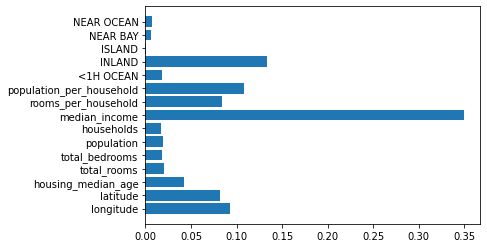

In [223]:
plt.barh(y=features, width=feature_importances.tolist())

In [224]:
final_model = grid_search.best_estimator_

final_predictions = final_model.predict(test_data)

final_mse = mean_squared_error(test_labels, final_predictions)
final_rmse = np.sqrt(final_mse)

In [225]:
final_rmse

65931.1020241699